# Logistic Regression Classifier

This notebook trains a Logistic Regression model on the Dry Bean dataset, evaluates its performance, and visualizes the confusion matrix.

In [ ]:
import io
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
import zipfile # Added for zip file handling
from io import BytesIO # Added for in-memory byte streams
import scipy.io.arff as arff # Added for ARFF file handling

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

In [ ]:
DATASET_CANDIDATES = [
    Path('dry_bean.csv'),
    Path('dry_bean_dataset.csv'),
    Path('Dry_Bean_Dataset.csv'),
]
DATASET_URL = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'

def load_dataset():
    for path in DATASET_CANDIDATES:
        if path.exists():
            return pd.read_csv(path)

    response = requests.get(DATASET_URL, timeout=60)
    response.raise_for_status()

    if response.headers.get('Content-Type', '').startswith('application/zip') or response.url.endswith('.zip'):
        with zipfile.ZipFile(BytesIO(response.content)) as archive:
            arff_name = next(name for name in archive.namelist() if name.endswith('.arff'))
            # Wrap the binary stream with io.TextIOWrapper to read it as text
            with io.TextIOWrapper(archive.open(arff_name), encoding='utf-8') as arff_file:
                raw_data, _ = arff.loadarff(arff_file)
            df = pd.DataFrame(raw_data)

            for col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].apply(lambda value: value.decode('utf-8') if isinstance(value, (bytes, bytearray)) else value)
            return df
    else:
        return pd.read_csv(io.StringIO(response.text))

df = load_dataset()
print(df.head())
print('\nClass distribution:')
print(df['Class'].value_counts())

      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395.0    610.291       208.178117       173.888747      1.197191   
1  28734.0    638.018       200.524796       182.734419      1.097356   
2  29380.0    624.110       212.826130       175.931143      1.209713   
3  30008.0    645.884       210.557999       182.516516      1.153638   
4  30140.0    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812     28715.0     190.141097  0.763923  0.988856   0.958027   
1      0.411785     29172.0     191.272750  0.783968  0.984986   0.887034   
2      0.562727     29690.0     193.410904  0.778113  0.989559   0.947849   
3      0.498616     30724.0     195.467062  0.782681  0.976696   0.903936   
4      0.333680     30417.0     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358    

In [ ]:
X = df.drop(columns=['Class']).astype(float)
y = df['Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42),
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

metrics = {
    'Accuracy': accuracy,
    'AUC': auc,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'MCC': mcc,
}
print('\nEvaluation metrics:')
print(pd.DataFrame(metrics, index=['Score']).T.round(4))

Classification report:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723


Evaluation metrics:
            Score
Accuracy   0.9214
AUC        0.9948
Precision  0.9222
Recall     0.9214
F1 Score   0.9216
MCC        0.9050


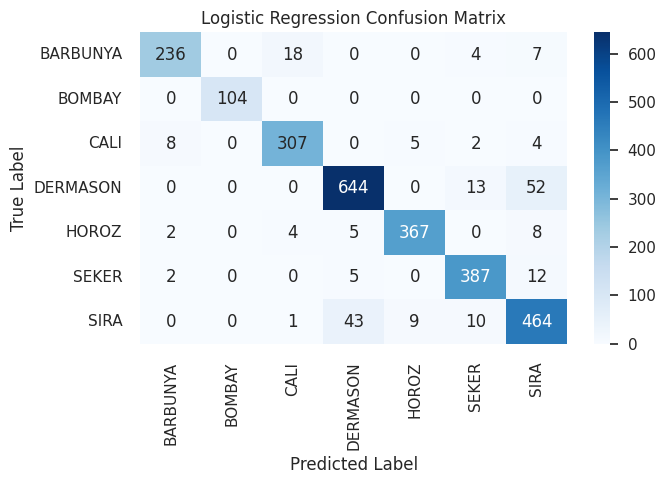

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_names = label_encoder.classes_

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
output_dir = Path('model')
output_dir.mkdir(exist_ok=True, parents=True)
joblib.dump(model, output_dir / 'logistic_regression.joblib')
print(f'Saved model to {output_dir / "logistic_regression.joblib"}')

Saved model to model/logistic_regression.joblib
